In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU - HARUS GANTI KE GPU!")

GPU available: True
Device: Tesla T4


In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'

!pip install wandb -q
import wandb
wandb.init(mode="disabled")

print("wandb dimatikan")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


wandb dimatikan


In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'

!rm -rf /content/yolov5
!rm -rf /content/runs

!git clone https://github.com/ultralytics/yolov5
%cd /content/yolov5
!pip install -r requirements.txt -q

import torch
print("\nGPU:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "MASIH CPU!")

Cloning into 'yolov5'...
remote: Enumerating objects: 18320, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 18320 (delta 26), reused 18 (delta 12), pack-reused 18264 (from 2)
Receiving objects: 100% (18320/18320), 17.45 MiB | 8.64 MiB/s, done.
Resolving deltas: 100% (12445/12445), done.
/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 14.2 MB/s eta 0:00:00

GPU: True
Device: Tesla T4


In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'

!pip install roboflow -q
from roboflow import Roboflow

rf = Roboflow(api_key="vnG3wVcnKUECpJo9pYge")
project = rf.workspace("ghanis-workspace-cjm94").project("coba-projek-uas")
version = project.version(1)
dataset = version.download("yolov5")

print("Dataset path:", dataset.location)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 94.2 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to coba-projek-uas-1 in yolov5pytorch:: 100%|██████████| 15004/15004 [00:02<00:00, 6407.99it/s] 


Dataset path: /content/yolov5/coba-projek-uas-1


In [ ]:
import yaml, os

yaml_path = os.path.join(dataset.location, "data.yaml")

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['names'] = ['Kosong', 'Terisi', 'Penuh']
data['nc'] = 3

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("data.yaml updated")
with open(yaml_path, 'r') as f:
    print(f.read())

data.yaml updated
names:
- Kosong
- Terisi
- Penuh
nc: 3
roboflow:
  license: CC BY 4.0
  project: coba-projek-uas
  url: https://universe.roboflow.com/ghanis-workspace-cjm94/coba-projek-uas/dataset/1
  version: 1
  workspace: ghanis-workspace-cjm94
test: ../test/images
train: coba-projek-uas-1/train/images
val: coba-projek-uas-1/valid/images



In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'

yaml_path = os.path.join(dataset.location, "data.yaml")

%cd /content/yolov5

!python train.py \
    --img 640 \
    --batch 16 \
    --epochs 15 \
    --data {yaml_path} \
    --weights yolov5s.pt \
    --freeze 10 \
    --project runs/train \
    --name tl_phase1_freeze \
    --exist-ok \
    --cache disk \
    --hyp data/hyps/hyp.scratch-low.yaml \
    --device 0

Output streaming akan dipotong hingga 5000 baris terakhir.
  with torch.cuda.amp.autocast(amp):
       8/14      2.25G     0.0135    0.01151    0.01694         50        640:  40% 149/375 [00:53<01:26,  2.60it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
       8/14      2.25G    0.01349    0.01153    0.01696         47        640:  40% 150/375 [00:53<01:08,  3.29it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
       8/14      2.25G    0.01349    0.01153    0.01694         50        640:  40% 151/375 [00:54<01:30,  2.47it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.a

In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'

yaml_path = os.path.join(dataset.location, "data.yaml")

%cd /content/yolov5

!python train.py \
    --img 640 \
    --batch 16 \
    --epochs 15 \
    --data {yaml_path} \
    --weights /content/yolov5/runs/train/tl_phase1_freeze/weights/best.pt \
    --project runs/train \
    --name tl_phase2_finetune \
    --exist-ok \
    --cache disk \
    --hyp data/hyps/hyp.scratch-low.yaml \
    --device 0

Output streaming akan dipotong hingga 5000 baris terakhir.
  with torch.cuda.amp.autocast(amp):
       8/14      4.33G   0.009702   0.007616    0.01092         50        640:  40% 149/375 [00:59<01:47,  2.11it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
       8/14      4.33G   0.009701   0.007616    0.01093         47        640:  40% 150/375 [01:00<01:42,  2.21it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
       8/14      4.33G     0.0097    0.00762    0.01091         50        640:  40% 151/375 [01:00<01:31,  2.45it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.a

In [ ]:
import os
os.environ['WANDB_DISABLED'] = 'true'

yaml_path = os.path.join(dataset.location, "data.yaml")

%cd /content/yolov5

!python val.py \
    --weights /content/yolov5/runs/train/tl_phase2_finetune/weights/best.pt \
    --data {yaml_path} \
    --img 640 \
    --task val \
    --name validasi_final \
    --device 0

/content/yolov5
val: data=/content/yolov5/coba-projek-uas-1/data.yaml, weights=['/content/yolov5/runs/train/tl_phase2_finetune/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=validasi_final, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-501-g88384748 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/yolov5/coba-projek-uas-1/valid/labels.cache... 1500 images, 0 backgrounds, 0 corrupt: 100% 1500/1500 [00:00<?, ?it/s]
val: WARNING ⚠️ /content/yolov5/coba-projek-uas-1/valid/images/Kosong_2058_jpg.rf.775a337c8642311fbf1fd83fcd564019.jpg: 1 duplicate labels removed
                 Class     Images  Instances          P          R      mAP50   mAP50-95

=== Phase 1 ===


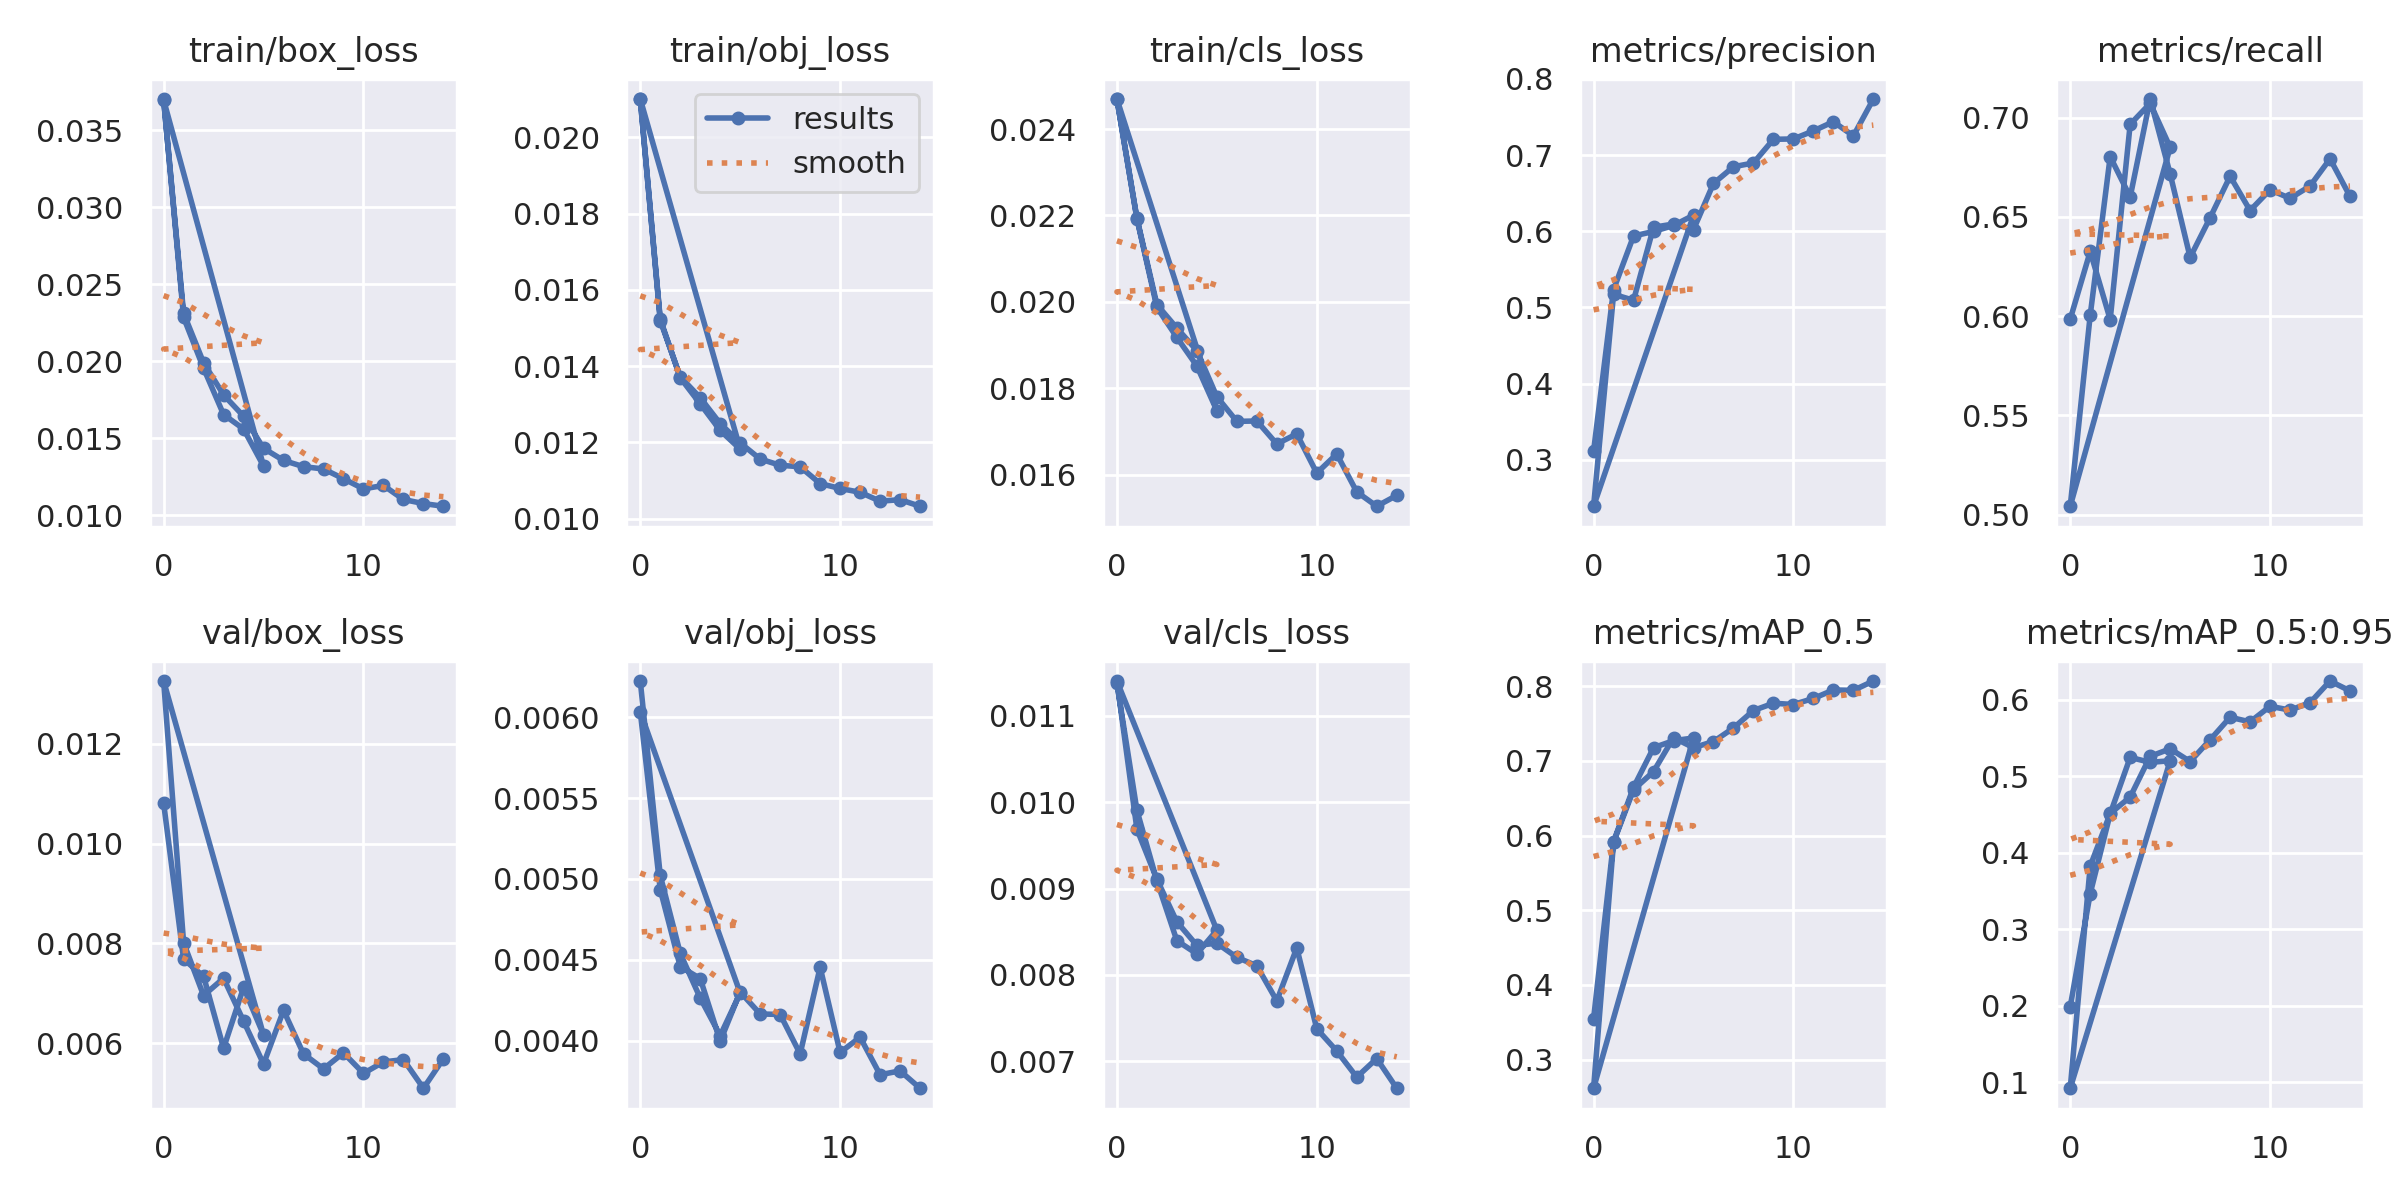

=== Phase 2 ===


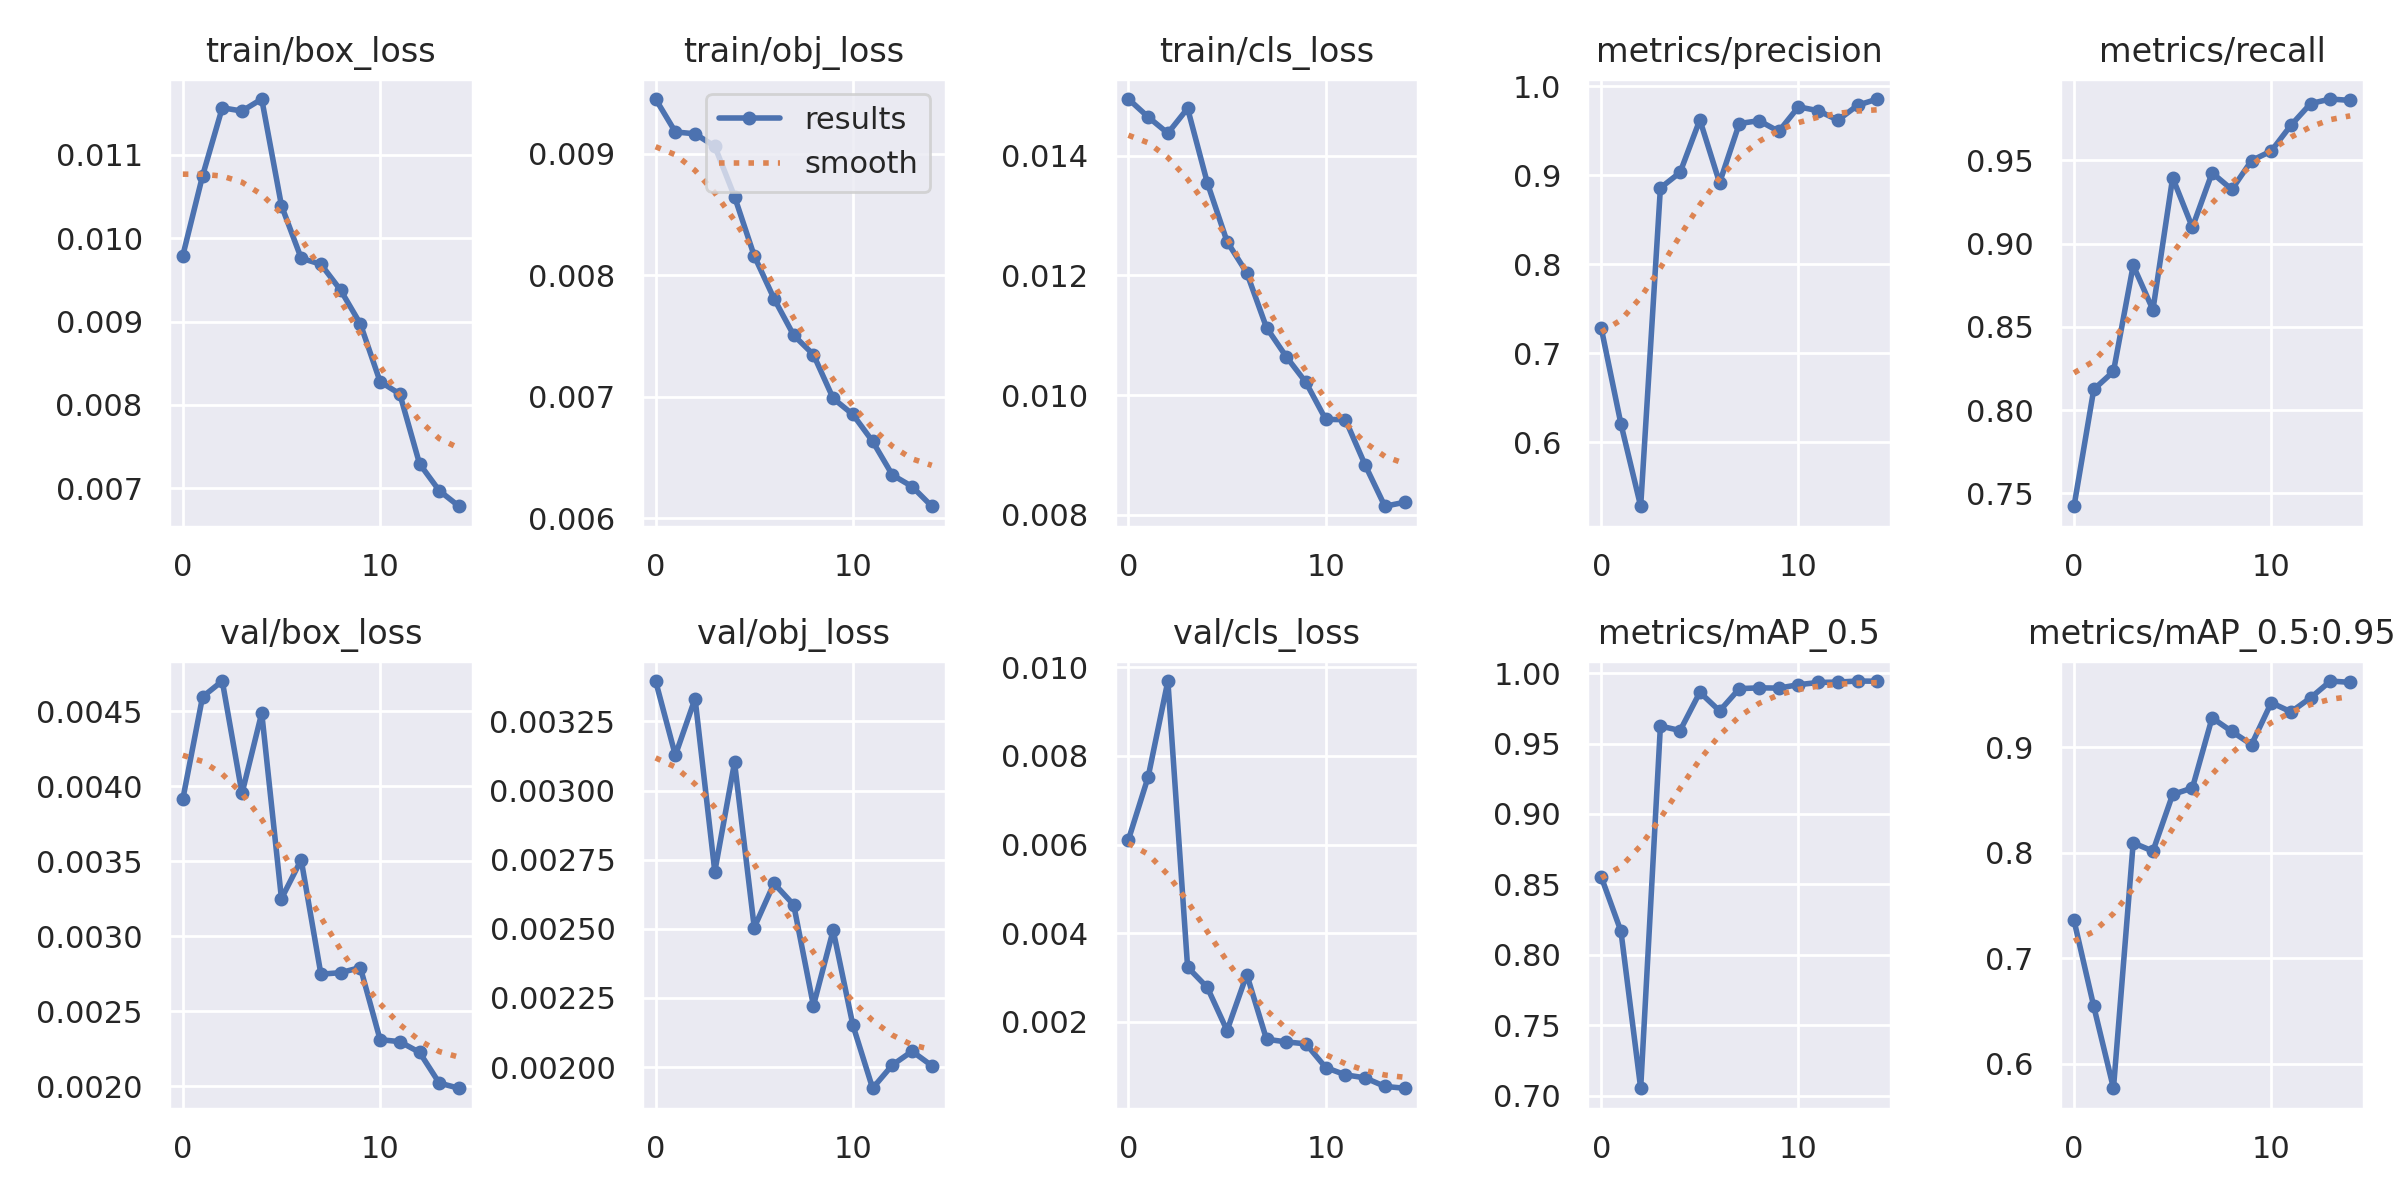

In [ ]:
from IPython.display import Image, display
import os

for name, path in [
    ("Phase 1", "/content/yolov5/runs/train/tl_phase1_freeze/results.png"),
    ("Phase 2", "/content/yolov5/runs/train/tl_phase2_finetune/results.png"),
]:
    if os.path.exists(path):
        print(f"=== {name} ===")
        display(Image(path, width=900))
    else:
        print(f"{name}: belum ada")

=== Phase 1 (Freeze) ===


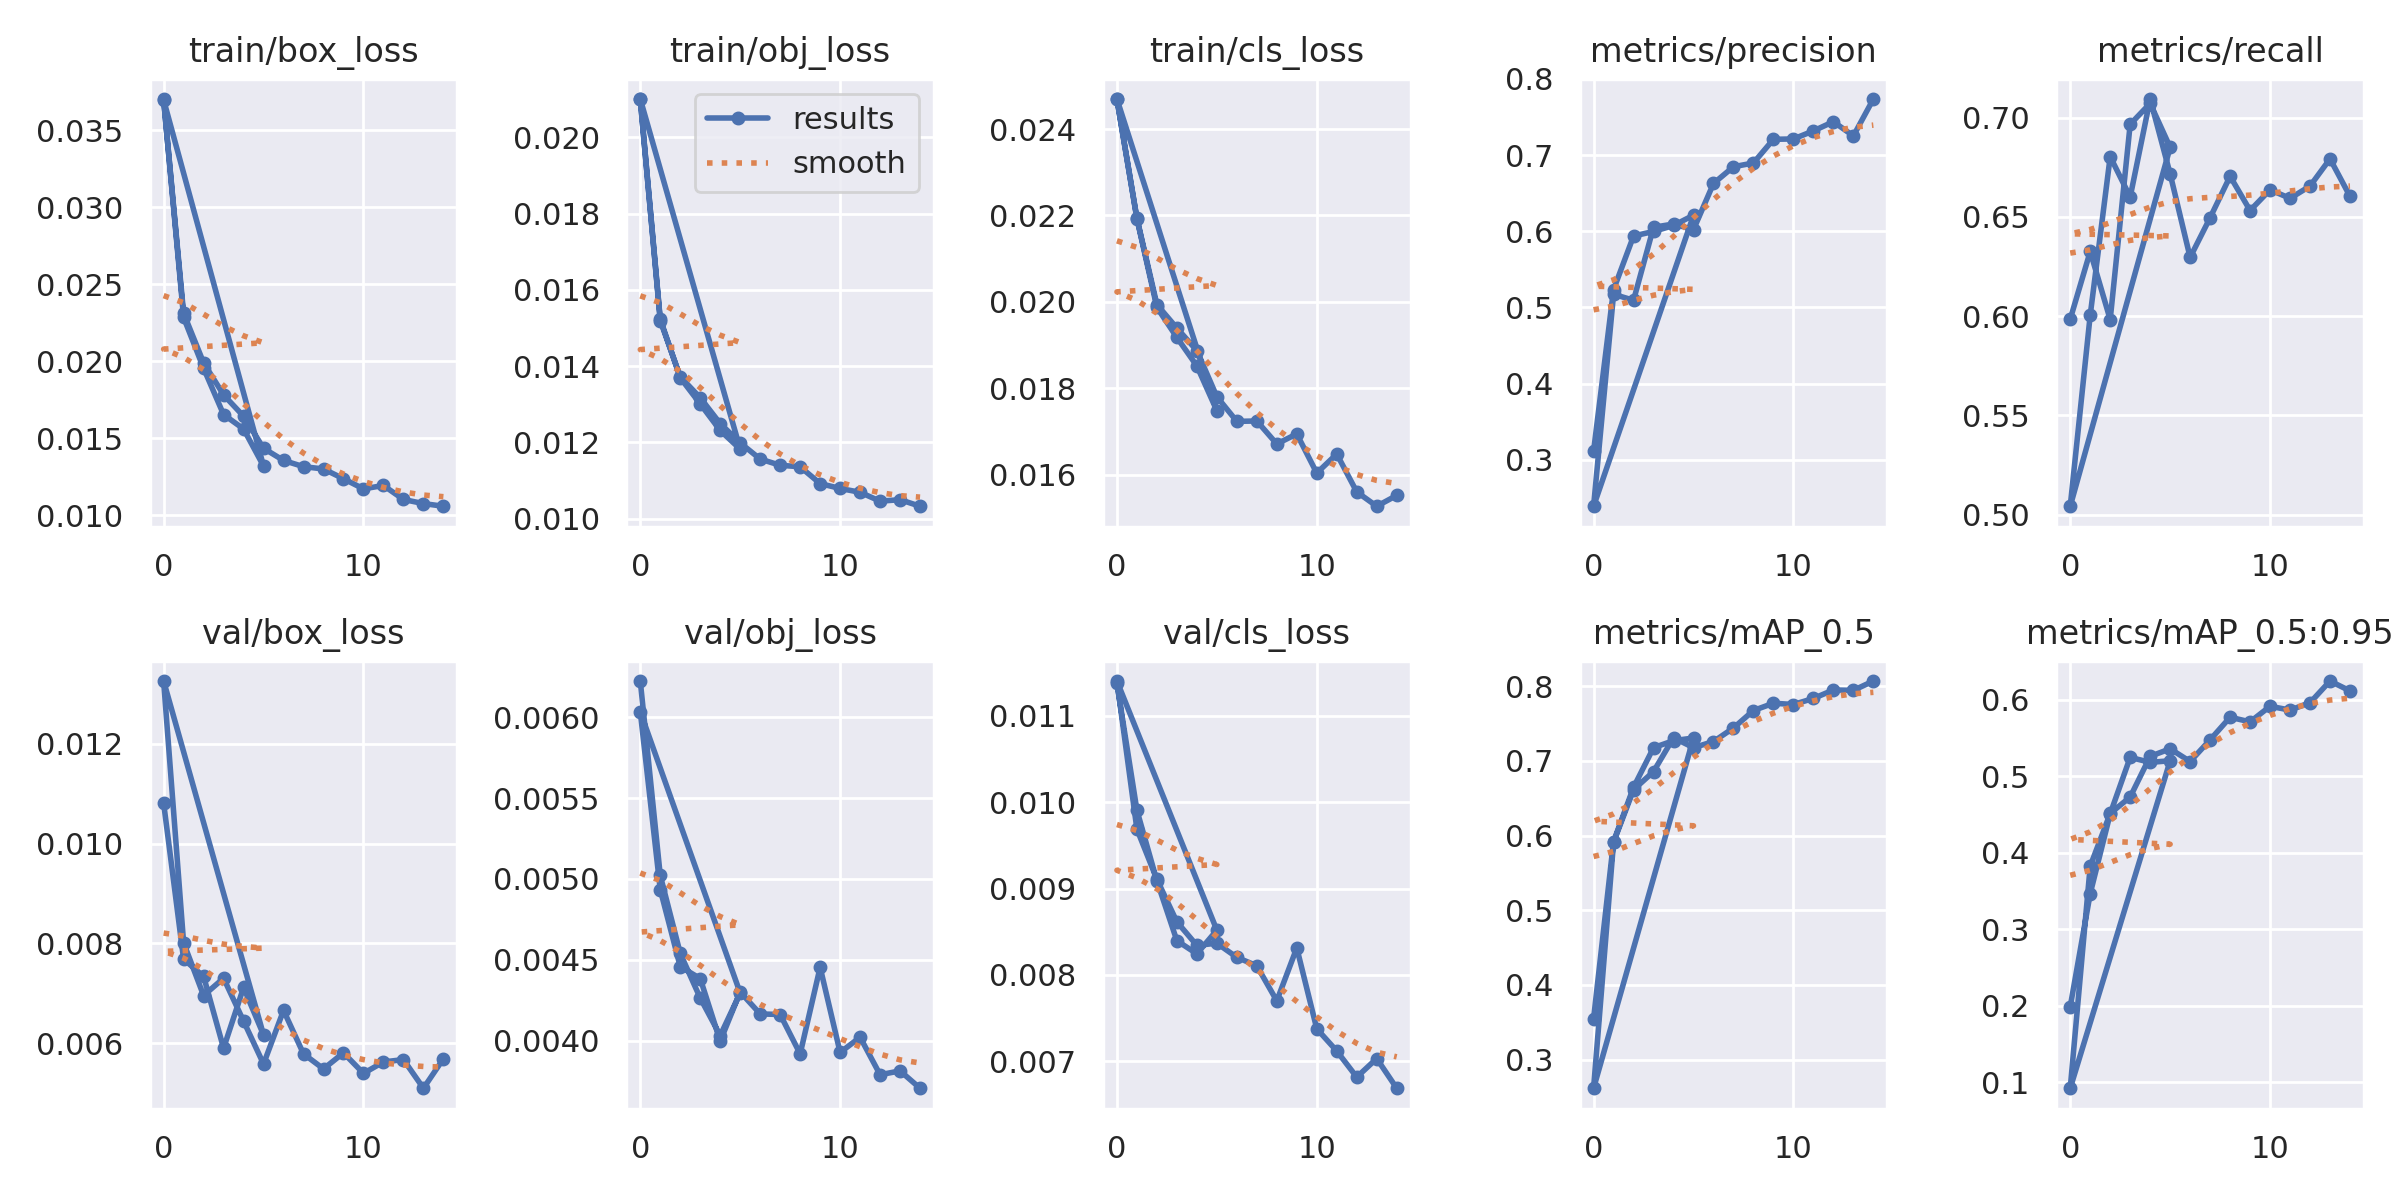

=== Phase 2 (Fine-tune) ===


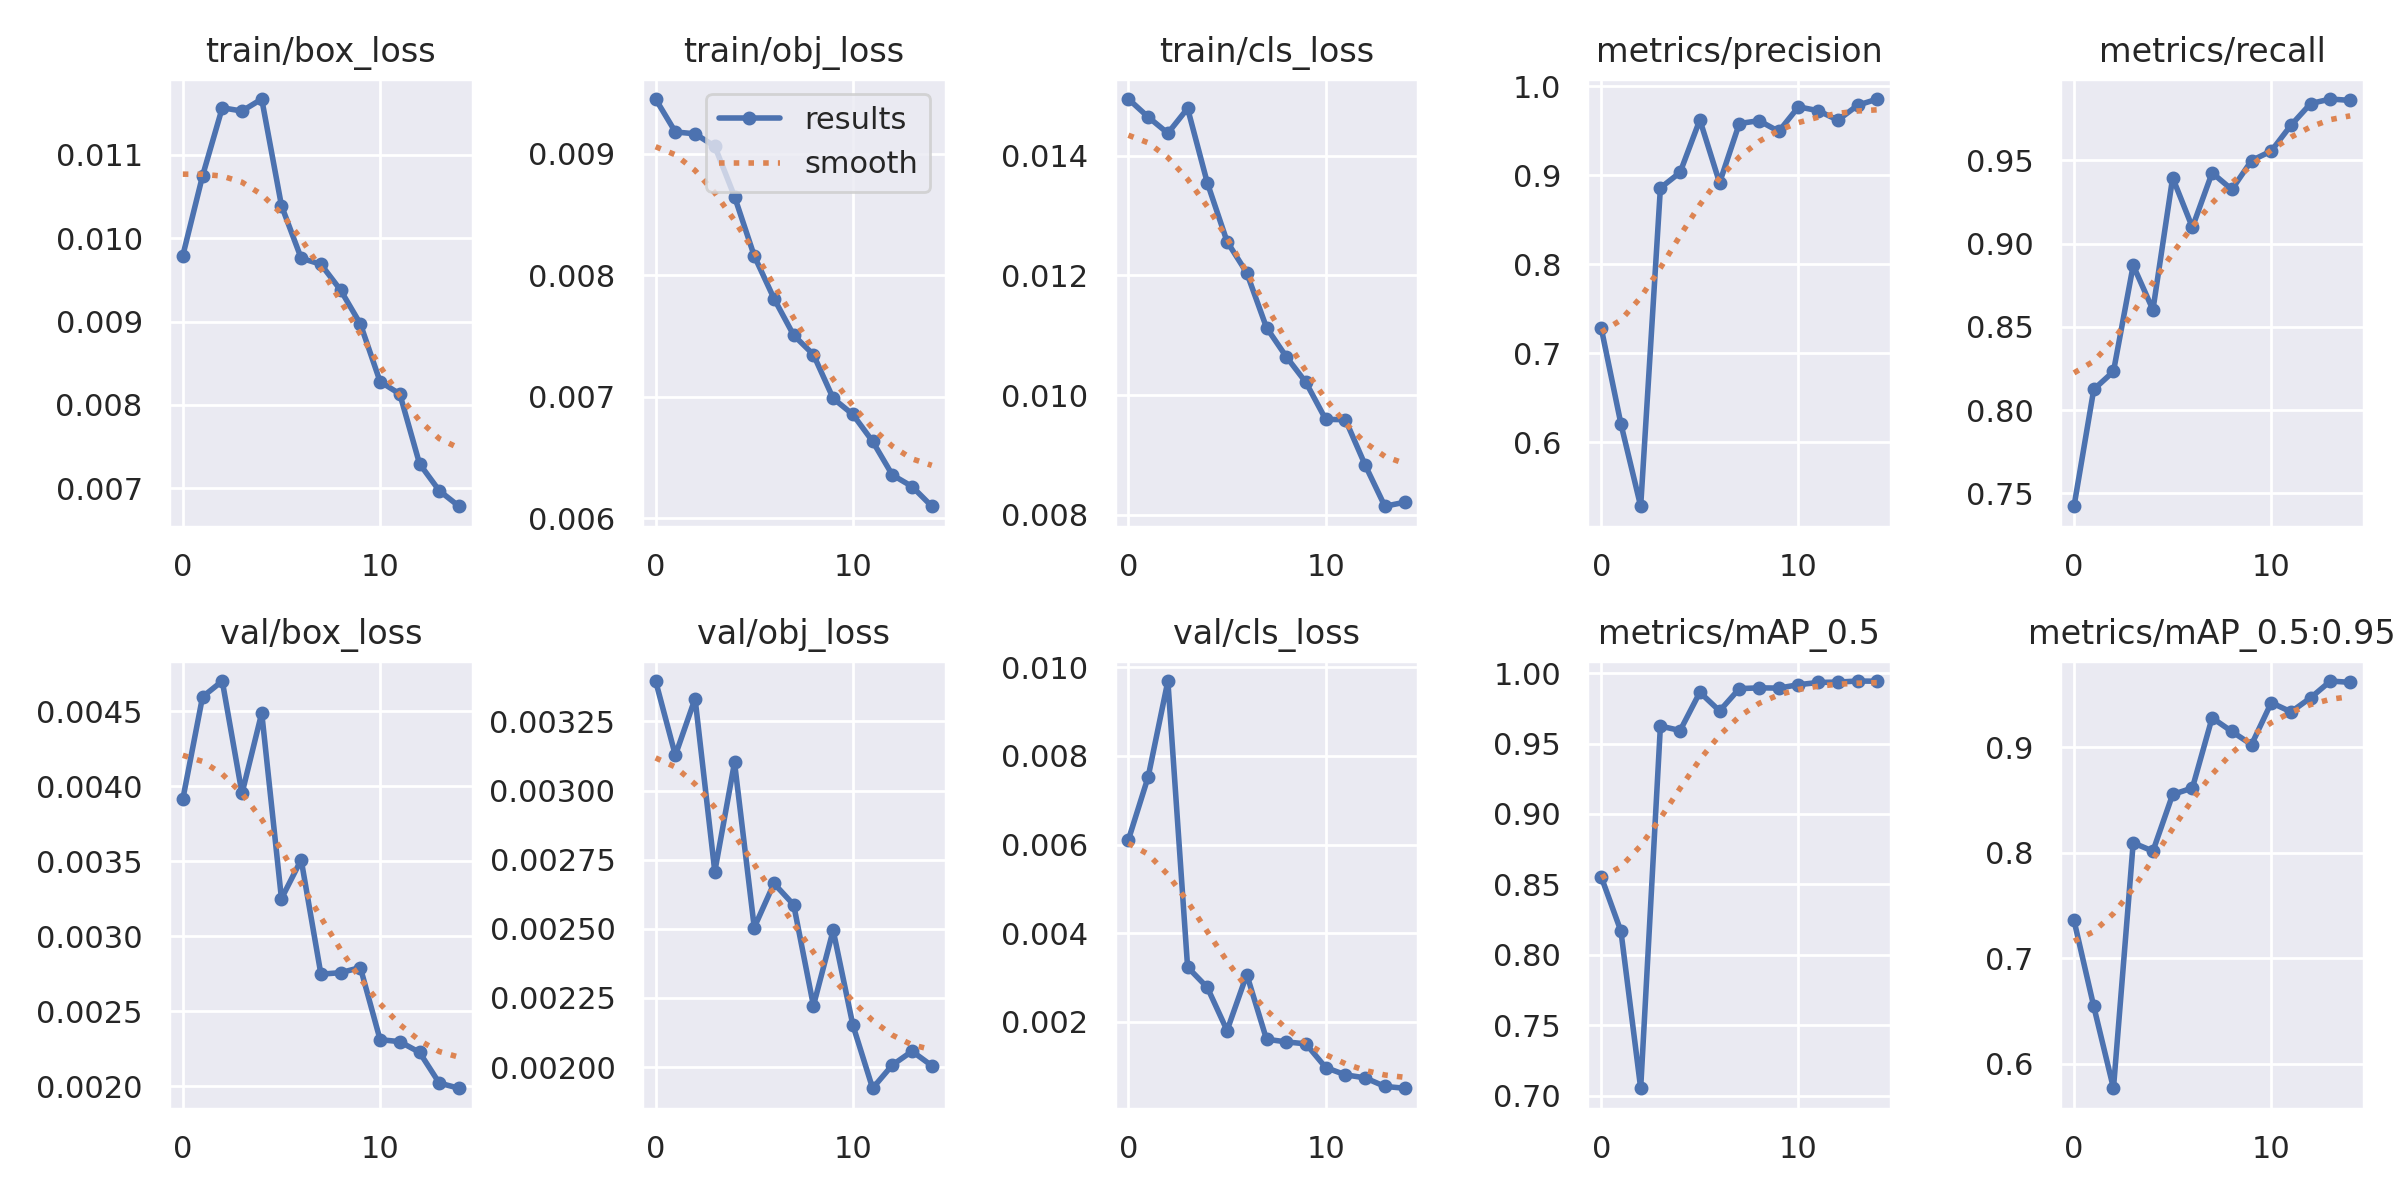

In [ ]:
from IPython.display import Image, display
import os

print("=== Phase 1 (Freeze) ===")
p1 = "runs/train/tl_phase1_freeze/results.png"
if os.path.exists(p1):
    display(Image(p1, width=900))
else:
    print("File belum ada, training mungkin belum selesai")

print("=== Phase 2 (Fine-tune) ===")
p2 = "runs/train/tl_phase2_finetune/results.png"
if os.path.exists(p2):
    display(Image(p2, width=900))
else:
    print("File belum ada, training mungkin belum selesai")

In [ ]:
import os
yaml_path = os.path.join(dataset.location, "data.yaml")

!python val.py \
    --weights runs/train/tl_phase2_finetune/weights/best.pt \
    --data {yaml_path} \
    --img 640 \
    --task val \
    --name validasi_final

val: data=/content/yolov5/coba-projek-uas-1/data.yaml, weights=['runs/train/tl_phase2_finetune/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=validasi_final, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-501-g88384748 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/yolov5/coba-projek-uas-1/valid/labels.cache... 1500 images, 0 backgrounds, 0 corrupt: 100% 1500/1500 [00:00<?, ?it/s]
val: WARNING ⚠️ /content/yolov5/coba-projek-uas-1/valid/images/Kosong_2058_jpg.rf.775a337c8642311fbf1fd83fcd564019.jpg: 1 duplicate labels removed
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 47/47 [00:21<00:00,  2.16i

pakai lime

In [ ]:
import os
import random

valid_dir = "/content/yolov5/coba-projek-uas-1/valid/images"

images = [
    os.path.join(valid_dir, f)
    for f in os.listdir(valid_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print(f"Jumlah gambar: {len(images)}")

Jumlah gambar: 1500


In [ ]:
import random

image_path = random.choice(images)

print(image_path)

/content/yolov5/coba-projek-uas-1/valid/images/Kosong_1628_jpg.rf.7245ab99194b117cddfb670c61006288.jpg


In [ ]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [ ]:
!pip install lime

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [ ]:
import torch

model = torch.hub.load(
    '/content/yolov5',
    'custom',
    path='/content/yolov5/runs/train/tl_phase2_finetune/weights/best.pt',
    source='local'
)

model.conf = 0.25

YOLOv5 🚀 v7.0-501-g88384748 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


In [ ]:
def predict_fn(images):

    preds = []

    for img in images:

        results = model(img)

        probs = np.zeros(3)

        if len(results.xyxy[0]) > 0:

            detections = results.xyxy[0].cpu().numpy()

            for det in detections:

                cls = int(det[5])
                conf = det[4]

                probs[cls] = max(probs[cls], conf)

        preds.append(probs)

    return np.array(preds)

In [ ]:
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    img,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=500
)

  0%|          | 0/500 [00:00<?, ?it/s]

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(arg

In [ ]:
from lime import lime_image

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

In [ ]:
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

img_lime = mark_boundaries(temp / 255.0, mask)

plt.figure()
plt.imshow(img_lime)
plt.axis('off')

plt.savefig("lime_result.png", bbox_inches='tight', pad_inches=0)
plt.show()

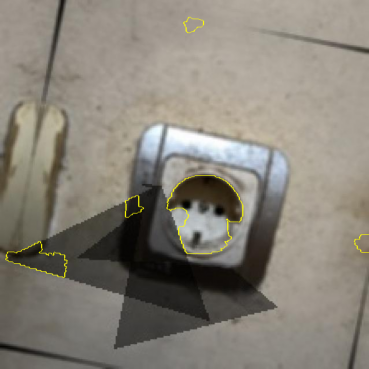

In [ ]:
from PIL import Image
from IPython.display import display

img = Image.open("/content/yolov5-gradcam/lime_result.png")
display(img)